<a href="https://colab.research.google.com/github/ArghyaRC96/metricguard-ai/blob/main/notebooks/04_lineage_impact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ MetricGuard AI — Lineage and Impact Analysis

## Notebook 04

This notebook uses the production MetricGuard lineage engine to inspect and
visualize Northstar Commerce analytics dependencies.

The production lineage logic lives in:

`src/metricguard/lineage/`

This notebook does not reimplement lineage extraction. It imports and uses the
production engine for experimentation, validation, and portfolio visualization.

In [2]:
from pathlib import Path
import shutil
import subprocess

GITHUB_USERNAME = "ArghyaRC96"

REPO_URL = f"https://github.com/{GITHUB_USERNAME}/metricguard-ai.git"
REPO_DIR = Path("/content/metricguard-ai")

if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

subprocess.run(
    ["git", "clone", REPO_URL, str(REPO_DIR)],
    check=True,
)

print("Repository cloned:", REPO_DIR)

Repository cloned: /content/metricguard-ai


In [3]:
%pip install -q -e "/content/metricguard-ai"

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for metricguard-ai (pyproject.toml) ... done


In [5]:
import sys

sys.path.append(
    "/content/metricguard-ai/src"
)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from metricguard.ingestion import (
    parse_knowledge_base,
)

from metricguard.lineage import (
    build_lineage_edges,
    build_lineage_graph,
    get_all_downstream,
    get_all_upstream,
    trace_asset,
    validate_lineage_graph,
)

In [7]:
RAW_DIR = REPO_DIR / "data" / "raw"

documents, errors = parse_knowledge_base(
    source_root=RAW_DIR,
    repo_root=REPO_DIR,
)

assert errors == []

edges = build_lineage_edges(
    documents
)

graph = build_lineage_graph(
    edges
)

validate_lineage_graph(
    graph
)

print("Documents:", len(documents))
print("Nodes:", graph.number_of_nodes())
print("Edges:", graph.number_of_edges())

Documents: 55
Nodes: 33
Edges: 30


In [8]:
edge_df = pd.DataFrame(
    [
        edge.to_dict()
        for edge in edges
    ]
)

edge_df.head(20)

,upstream,downstream,relationship,source_path
0,fct_orders,active_customers_v2,sql_dependency,data/raw/sql/metrics/active_customers_v2.sql
1,fct_orders,mart_executive_daily,sql_dependency,data/raw/sql/marts/mart_executive_daily.sql
2,fct_orders,mart_finance_daily,sql_dependency,data/raw/sql/marts/mart_finance_daily.sql
3,fct_orders,mart_operations_daily,sql_dependency,data/raw/sql/marts/mart_operations_daily.sql
4,fct_orders,net_revenue_v1,sql_dependency,data/raw/sql/metrics/net_revenue_v1.sql
5,fct_orders,net_revenue_v2,sql_dependency,data/raw/sql/metrics/net_revenue_v2.sql
6,fct_orders,net_revenue_v3,sql_dependency,data/raw/sql/metrics/net_revenue_v3.sql
7,fct_orders,refund_rate_v1,sql_dependency,data/raw/sql/metrics/refund_rate_v1.sql
8,fct_orders,refund_rate_v2,sql_dependency,data/raw/sql/metrics/refund_rate_v2.sql
9,fct_orders,total_orders_v1,sql_dependency,data/raw/sql/metrics/total_orders_v1.sql


In [9]:
finance_upstream = get_all_upstream(
    graph,
    "Finance Revenue Dashboard",
)

finance_upstream

['fct_orders',
 'mart_finance_daily',
 'raw_orders',
 'raw_payments',
 'raw_refunds',
 'stg_orders',
 'stg_payments',
 'stg_refunds']

In [10]:
fct_orders_impact = get_all_downstream(
    graph,
    "fct_orders",
)

fct_orders_impact

['Executive KPI Dashboard',
 'Finance Revenue Dashboard',
 'Operations Dashboard',
 'active_customers_v2',
 'mart_executive_daily',
 'mart_finance_daily',
 'mart_operations_daily',
 'net_revenue_v1',
 'net_revenue_v2',
 'net_revenue_v3',
 'refund_rate_v1',
 'refund_rate_v2',
 'total_orders_v1',
 'total_orders_v2']

In [11]:
trace_asset(
    graph,
    "fct_orders",
)

{'asset': 'fct_orders',
 'direct_upstream': ['stg_orders', 'stg_payments', 'stg_refunds'],
 'all_upstream': ['raw_orders',
  'raw_payments',
  'raw_refunds',
  'stg_orders',
  'stg_payments',
  'stg_refunds'],
 'direct_downstream': ['active_customers_v2',
  'mart_executive_daily',
  'mart_finance_daily',
  'mart_operations_daily',
  'net_revenue_v1',
  'net_revenue_v2',
  'net_revenue_v3',
  'refund_rate_v1',
  'refund_rate_v2',
  'total_orders_v1',
  'total_orders_v2'],
 'all_downstream': ['Executive KPI Dashboard',
  'Finance Revenue Dashboard',
  'Operations Dashboard',
  'active_customers_v2',
  'mart_executive_daily',
  'mart_finance_daily',
  'mart_operations_daily',
  'net_revenue_v1',
  'net_revenue_v2',
  'net_revenue_v3',
  'refund_rate_v1',
  'refund_rate_v2',
  'total_orders_v1',
  'total_orders_v2']}

In [12]:
focus_nodes = {
    "raw_orders",
    "raw_payments",
    "raw_refunds",
    "stg_orders",
    "stg_payments",
    "stg_refunds",
    "fct_orders",
    "mart_finance_daily",
    "mart_executive_daily",
    "Finance Revenue Dashboard",
    "Executive KPI Dashboard",
}

available_nodes = (
    focus_nodes
    & set(graph.nodes)
)

revenue_graph = graph.subgraph(
    available_nodes
).copy()

print(
    "Focused nodes:",
    len(revenue_graph.nodes)
)

print(
    "Focused edges:",
    len(revenue_graph.edges)
)

Focused nodes: 11
Focused edges: 10


## Drawing Focsed Graph

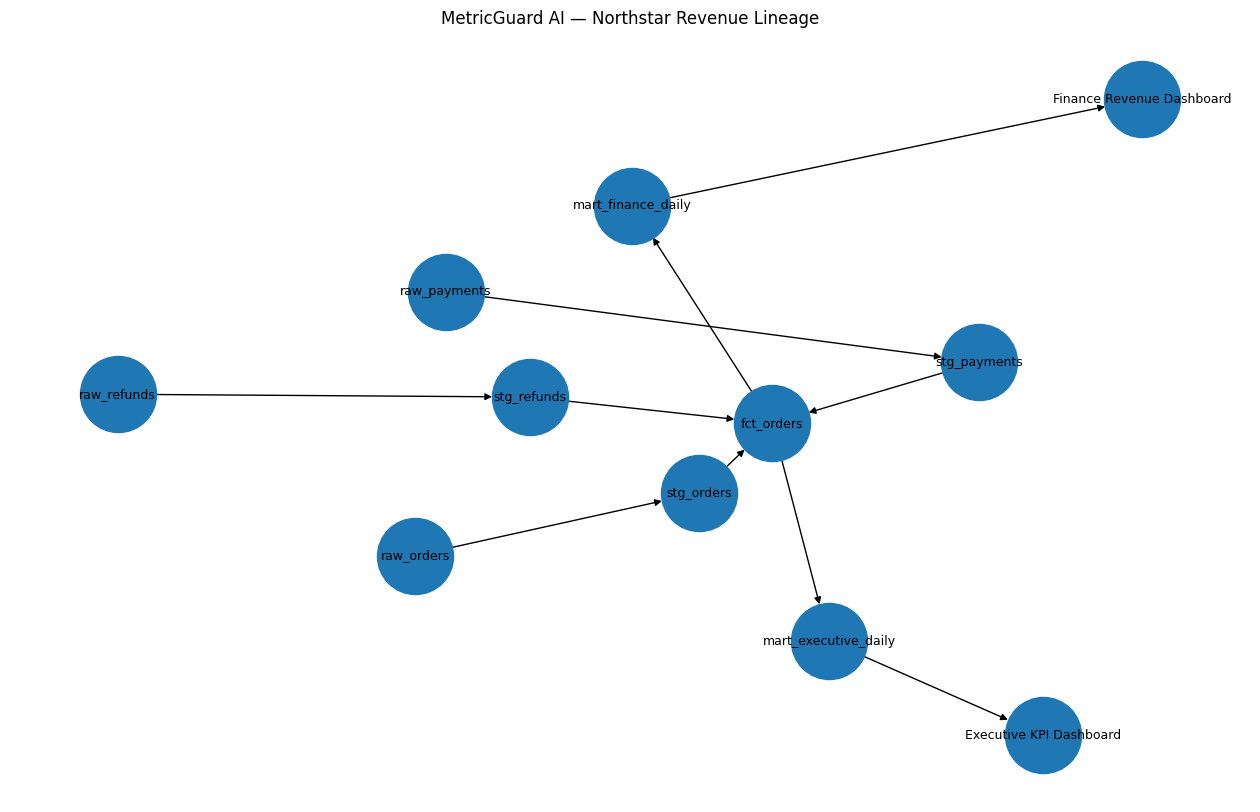

In [13]:
plt.figure(
    figsize=(16, 10)
)

positions = nx.spring_layout(
    revenue_graph,
    seed=42,
)

nx.draw_networkx(
    revenue_graph,
    pos=positions,
    with_labels=True,
    node_size=3000,
    font_size=9,
    arrows=True,
)

plt.title(
    "MetricGuard AI — Northstar Revenue Lineage"
)

plt.axis("off")
plt.show()

In [14]:
import json

GROUND_TRUTH_PATH = (
    REPO_DIR
    / "data"
    / "ground_truth"
    / "expected_lineage.json"
)

with GROUND_TRUTH_PATH.open(
    "r",
    encoding="utf-8-sig",
) as file:

    expected_lineage = json.load(file)

In [15]:
expected_edges = {
    tuple(edge)
    for edge in expected_lineage["edges"]
}

actual_edges = {
    (
        upstream,
        downstream,
    )
    for upstream, downstream
    in graph.edges
}

missing_edges = (
    expected_edges
    - actual_edges
)

unexpected_edges = (
    actual_edges
    - expected_edges
)

print(
    "Expected edges:",
    len(expected_edges)
)

print(
    "Missing expected edges:",
    len(missing_edges)
)

print(
    "Additional discovered edges:",
    len(unexpected_edges)
)

print(
    "Missing:",
    sorted(missing_edges)
)

Expected edges: 18
Missing expected edges: 0
Additional discovered edges: 12
Missing: []


## Phase 5 Lineage Summary

MetricGuard now computes lineage deterministically from source SQL and
dashboard metadata.

### Production behavior

- SQLGlot parses real SQL dependencies.
- CTE aliases are excluded from external lineage.
- NetworkX builds the directed dependency graph.
- Upstream lineage can be traced transitively.
- Downstream impact can be calculated transitively.
- Dashboard dependencies extend warehouse lineage to reporting assets.
- Retrieval chunks are enriched with lineage and impact metadata.

### Evaluation

Ground-truth lineage is used only after graph construction for evaluation.
It is never included in the RAG knowledge base.

### Next

The fully enriched retrieval chunks are ready for embedding generation and
vector storage in Qdrant.